<h3>1.Import & Initial Inspection</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the dataset
dfhd = pd.read_csv("heartdisease.csv")

In [3]:
#Display the first 5 rows, the dataset shape, and the column data types.
print(dfhd.head(5))
print(dfhd.shape)
print(dfhd.dtypes)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
(303, 14)
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [4]:
#Use .isna().sum() to check for missing values.
missing_values = dfhd.isna().sum()
print(missing_values)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [5]:
#Use .describe() to summarize numeric columns.
print(dfhd.describe())

              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean     0.528053  149.646865    0.326733    1.039604    1.399340    0.729373   
std      0.525860   22.9051

<b>Briefly identify any potential outliers in chol, trestbps, thalach, and oldpeak based on summary statistics above.</b>

chol:The maximum value (564) is far above the 75th percentile (274.5) and much larger than the mean (246.3), indicating strong high-end outliers. The large standard deviation also supports this.

trestbps:The maximum (200) is notably higher than the 75th percentile (140) and mean (131.6), suggesting some high outliers, though less extreme than cholesterol.

thalach :The minimum (71) is well below the 25th percentile (133.5), indicating possible low-end outliers. The upper end (max = 202) is not extreme relative to Q3.

oldpeak:Most values are clustered near 0 (median = 0.8, Q1 = 0.0), while the maximum (6.2) is much higher than the 75th percentile (1.6), indicating clear high-end outliers.

<h3>2.Cleaning & Preparation</h3>

<b>If missing values appear, handle them by dropping or using a simple imputation method (explain your choice in 1–2 sentences).

Missing values not found, so no dropping/imputation needed.

In [6]:
#Convert categorical or binary columns (e.g., sex, cp, fbs, restecg) to appropriate data types.

#Binary Columns (0/1) to category
binary_cols = ["sex","fbs","exang","target"]
for col in binary_cols:
    dfhd[col] =dfhd[col].astype("category")

#Categorial to category
categorial_cols = ["cp","restecg","slope","thal","ca"]
for col in categorial_cols:
    dfhd[col] =dfhd[col].astype("category")

dfhd.dtypes

age            int64
sex         category
cp          category
trestbps       int64
chol           int64
fbs         category
restecg     category
thalach        int64
exang       category
oldpeak      float64
slope       category
ca          category
thal        category
target      category
dtype: object

In [7]:
#Rename at least three columns for clarity (example: trestbps → resting_bp).
dfhd = dfhd.rename(columns={
    "trestbps":"resting_bp",
    "thalach":"max_hr",
    "oldpeak":"st_depression",
    "chol":"cholesterol"
})

In [8]:
#Create a cleaned DataFrame named df_clean, and display its first 10 rows.
df_clean = dfhd.copy()

print(df_clean.head(10))

   age sex cp  resting_bp  cholesterol fbs restecg  max_hr exang  \
0   63   1  3         145          233   1       0     150     0   
1   37   1  2         130          250   0       1     187     0   
2   41   0  1         130          204   0       0     172     0   
3   56   1  1         120          236   0       1     178     0   
4   57   0  0         120          354   0       1     163     1   
5   57   1  0         140          192   0       1     148     0   
6   56   0  1         140          294   0       0     153     0   
7   44   1  1         120          263   0       1     173     0   
8   52   1  2         172          199   1       1     162     0   
9   57   1  2         150          168   0       1     174     0   

   st_depression slope ca thal target  
0            2.3     0  0    1      1  
1            3.5     0  0    2      1  
2            1.4     2  0    2      1  
3            0.8     2  0    2      1  
4            0.6     2  0    2      1  
5          

<h3>3.Feature Engineering</h3>

In [9]:
#age_group – Convert age into categories (e.g., “young,” “middle,” “older”).
df_clean["age_group"] = pd.cut(df_clean["age"],
                               bins=[-np.inf,39,59,np.inf],
                               labels=["young","middle","older"])

In [10]:
#chol_ratio – Compute chol / age.
df_clean["chol_ratio"] = df_clean["cholesterol"] / df_clean["age"]

In [11]:
#risk_flag – Set risk_flag = 1 if (chol > 240 OR resting_bp > 140), else 0.
df_clean["risk_flag"] = ((df_clean["cholesterol"] > 240) | (df_clean["resting_bp"] > 140)).astype(int)

In [12]:
#bp_category – Classify resting blood pressure into categories (e.g., “normal,” “elevated,” “high”).
def bp_cat(x):
    if x < 120: return "normal"
    if x < 130: return "elevated"
    if x < 140: return "high_stage1"
    return "high_stage2"
df_clean["bp_category"] = df_clean["resting_bp"].apply(bp_cat).astype("category")

In [13]:
#log_chol – A log transformation of cholesterol to reduce skew.
df_clean["log_chol"] = np.log1p(df_clean["cholesterol"])

In [14]:
#is_senior – Set is_senior = 1 if age >= 60, else 0.
df_clean["is_senior"] = (df_clean["age"] >= 60).astype(int)

In [15]:
df_clean.head(10)

,age,sex,cp,resting_bp,cholesterol,fbs,restecg,max_hr,exang,st_depression,slope,ca,thal,target,age_group,chol_ratio,risk_flag,bp_category,log_chol,is_senior
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,older,3.698413,1,high_stage2,5.455321,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,young,6.756757,1,high_stage1,5.525453,0
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,middle,4.975610,0,high_stage1,5.323010,0
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,middle,4.214286,0,elevated,5.468060,0
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,middle,6.210526,1,elevated,5.872118,0
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1,middle,3.368421,0,high_stage2,5.262690,0
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1,middle,5.250000,1,high_stage2,5.686975,0
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1,middle,5.977273,1,elevated,5.575949,0
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1,middle,3.826923,1,high_stage2,5.298317,0
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1,middle,2.947368,1,high_stage2,5.129899,0


<h3>4.Descriptive Statistics</h3>

In [16]:
#For the variables age, resting_bp, chol, and thalach, compute:mean,median,standard deviation,variance,IQR (Q3 − Q1),skewness,kurtosis
cols = ["age", "resting_bp", "cholesterol", "max_hr"]
li_stats=[]
for col in cols:
    li_stats.append({
        "variable": col,
        "mean": df_clean[col].mean(),
        "median": df_clean[col].median(),
        "std_dev": df_clean[col].std(),
        "variance": df_clean[col].var(),
        "IQR": df_clean[col].quantile(0.75) - df_clean[col].quantile(0.25),
        "skewness": df_clean[col].skew(),
        "kurtosis": df_clean[col].kurtosis()
    })


df_stats= pd.DataFrame(li_stats)
print(df_stats)


      variable        mean  median    std_dev     variance   IQR  skewness  \
0          age   54.366337    55.0   9.082101    82.484558  13.5 -0.202463   
1   resting_bp  131.623762   130.0  17.538143   307.586453  20.0  0.713768   
2  cholesterol  246.264026   240.0  51.830751  2686.426748  63.5  1.143401   
3       max_hr  149.646865   153.0  22.905161   524.646406  32.5 -0.537410   

   kurtosis  
0 -0.542167  
1  0.929054  
2  4.505423  
3 -0.061970  


The variable 'cholesterol' is right-skewed because its skewness value is high and the maximum value is much larger than the median. This shows that some patients have very high cholesterol levels. The variable 'cholesterol' also has high kurtosis, which means it has heavy tails and extreme values (outliers).</br>
The variable 'resting_bp' is also slightly right-skewed, which means there are some patients with higher blood pressure than most others. </br>
The variable 'max_hr' is left-skewed, meaning more values are high, but a few patients have very low maximum heart rate. </br>
These patterns are important because extreme cholesterol or blood pressure values can strongly increase the risk of heart disease and should be carefully considered in medical analysis and prediction models. 

<h3> 5.Visualizations </h3>

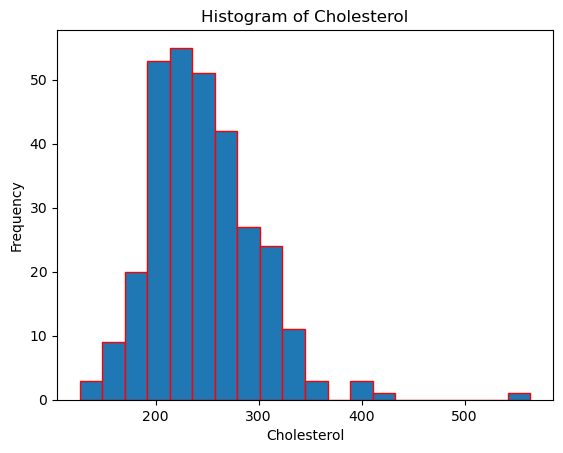

In [17]:
# 1. Histogram of cholesterol
plt.figure()
plt.hist(df_clean["cholesterol"], bins=20, edgecolor="red")
plt.title("Histogram of Cholesterol")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")
plt.show()

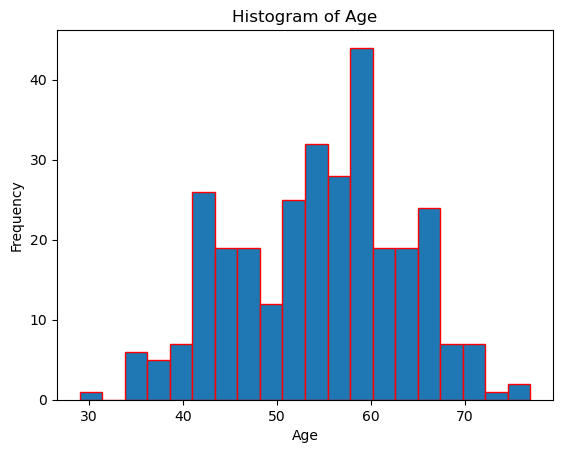

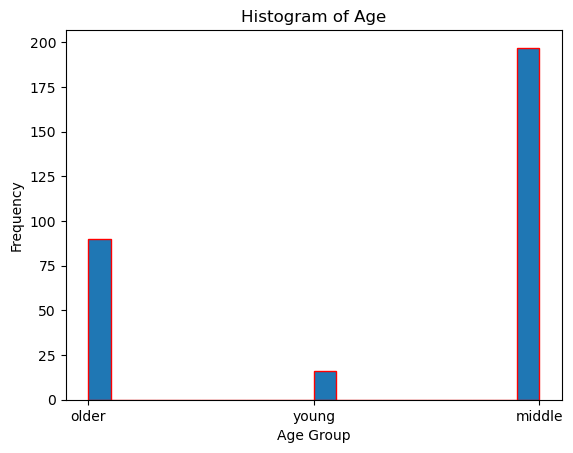

In [18]:
# 2. Histogram of age
plt.figure()
plt.hist(df_clean["age"], bins=20, edgecolor="red")
plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


plt.figure()
plt.hist(df_clean["age_group"], bins=20, edgecolor="red")
plt.title("Histogram of Age")
plt.xlabel("Age Group")
plt.ylabel("Frequency")
plt.show()

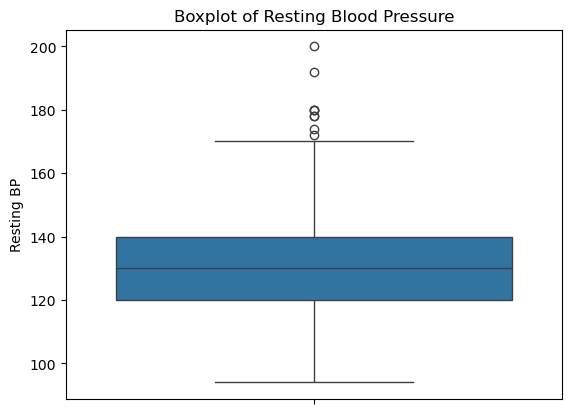

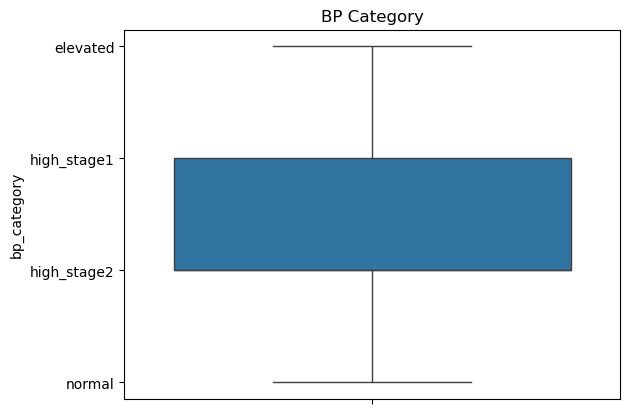

In [19]:
# 3. Boxplot of resting blood pressure
plt.figure()
sns.boxplot(y=df_clean["resting_bp"])
plt.title("Boxplot of Resting Blood Pressure")
plt.ylabel("Resting BP")
plt.show()


plt.figure()
sns.boxplot(y=df_clean["bp_category"])
plt.title("BP Category")
plt.show()


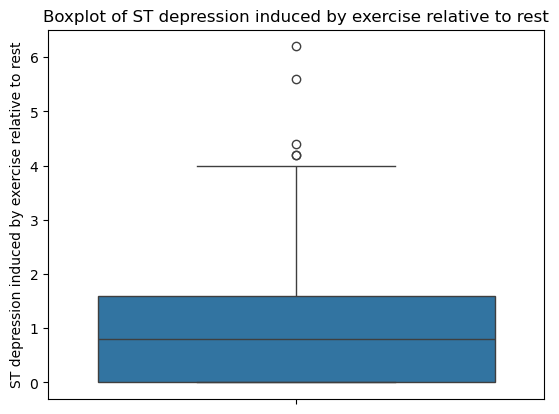

In [20]:
# 4. Boxplot of oldpeak
plt.figure()
sns.boxplot(y=df_clean["st_depression"])
plt.title("Boxplot of ST depression induced by exercise relative to rest")
plt.ylabel("ST depression induced by exercise relative to rest")
plt.show()


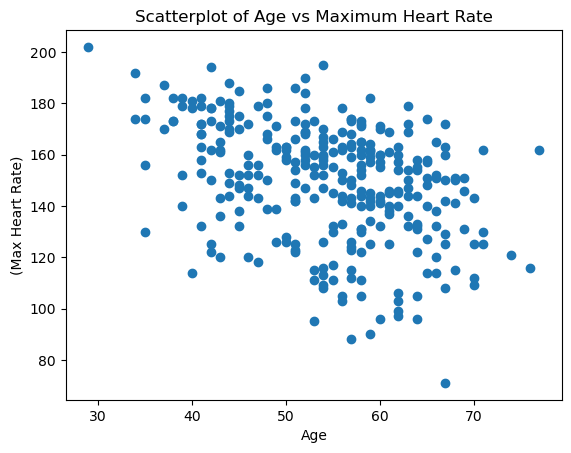

In [21]:
# 5. Scatterplot: age vs thalach
plt.figure()
plt.scatter(df_clean["age"], df_clean["max_hr"])
plt.title("Scatterplot of Age vs Maximum Heart Rate")
plt.xlabel("Age")
plt.ylabel("(Max Heart Rate)")
plt.show()


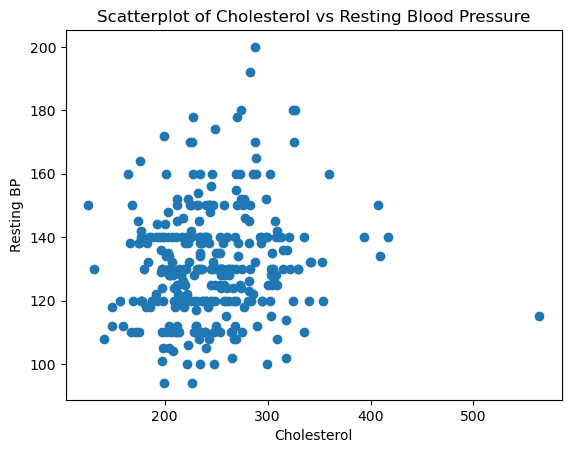

In [22]:
# 6. Scatterplot: cholesterol vs resting_bp
plt.figure()
plt.scatter(df_clean["cholesterol"], df_clean["resting_bp"])
plt.title("Scatterplot of Cholesterol vs Resting Blood Pressure")
plt.xlabel("Cholesterol")
plt.ylabel("Resting BP")
plt.show()

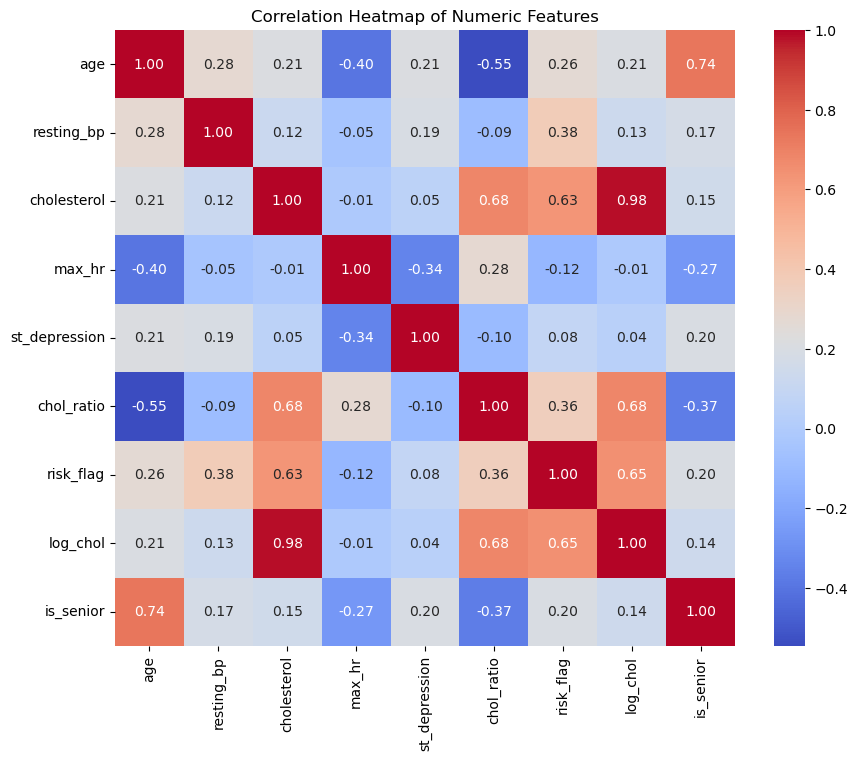

In [23]:
# 7. Correlation heatmap for all numeric features
plt.figure(figsize=(10, 8))
df_numeric = df_clean.select_dtypes(include=["int64", "float64"])
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


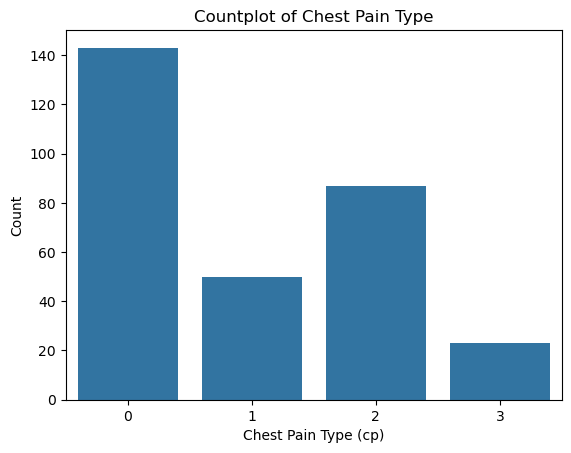

In [24]:
# 8. Countplot of cp (chest pain type)
plt.figure()
sns.countplot(x=df_clean["cp"])
plt.title("Countplot of Chest Pain Type")
plt.xlabel("Chest Pain Type (cp)")
plt.ylabel("Count")
plt.show()


<h3> 6.Exploratory Relationships</h3>

In [25]:
#Does thalach differ between males and females? (Use groupby + mean.)
thalach_by_sex = df_clean.groupby("sex", observed=True)["max_hr"].mean()
thalach_by_sex

sex
0    151.125000
1    148.961353
Name: max_hr, dtype: float64

In [26]:
#What is the average chol value for each age_group?
avg_chol_by_age = df_clean.groupby("age_group", observed=True)["cholesterol"].mean()
avg_chol_by_age

age_group
young     216.000000
middle    243.192893
older     258.366667
Name: cholesterol, dtype: float64

In [27]:
#Is risk_flag more common in older age groups?
risk_by_age = df_clean.groupby("age_group", observed=True)["risk_flag"].mean()
risk_by_age

age_group
young     0.187500
middle    0.558376
older     0.744444
Name: risk_flag, dtype: float64

In [28]:
#Create a pivot table of age_group × cp showing average chol.

pivot_table = pd.pivot_table(
    df_clean,
    values="cholesterol",
    index="age_group",
    columns="cp",
    aggfunc="mean" ,
    observed=True
)

pivot_table

cp,0,1,2,3
age_group,,,,
young,220.500000,202.000000,222.142857,206.500000
middle,250.078652,247.175000,229.464286,242.916667
older,252.600000,249.428571,281.291667,236.222222


The average maximum heart rate value is slightly different between males and females, which means maximum heart rate may vary by gender. The average cholesterol level increases from young to middle and older age groups, showing that cholesterol tends to be higher as people get older. The risk_flag is much more common in older age groups, which means older patients are more likely to have high cholesterol or high blood pressure. The pivot table shows that cholesterol levels also change across chest pain types within each age group. These relationships are important because they help doctors understand which groups have higher heart disease risk. This information can support better screening and prevention for older and higher-risk patients.

<h3> 7.CRISP-DM Reflection</h3>

In this assignment, Stage 1 (Business Understanding) and Stage 2 (Data Understanding) of the CRISP-DM process were completed.The business question was also defined as “Why are our patients waiting so long?”, the goal of this project was defined as understanding patterns related to heart disease risk using patient data. During the Data Understanding stage, the dataset was explored by checking the number of rows, column meanings, summary statistics, and distributions of key variables such as age, cholesterol, and blood pressure. Missing values and potential outliers were examined, similar to how invalid or negative wait times were checked in the clinic wait example.

The Modeling, Evaluation, and Deployment stages were not completed in this assignment; however, preparation for these stages was performed through feature creation and exploratory analysis. New variables such as age groups, blood pressure categories, and a risk flag were created in a way that aligns with the feature engineering step described in the Modeling stage of the lecture. If this were a real healthcare project, predictive models would be developed, evaluated using appropriate metrics, and deployed through reports or dashboards. Overall, the early CRISP-DM stages were followed, and a foundation for future modeling and decision-making was established.

<h3> 8.Final Summary </h3>

This analysis explored a heart disease dataset to understand patterns related to heart health risk. The dataset had no missing values, which allowed all records to be used in the analysis. Descriptive statistics showed that cholesterol and resting blood pressure were right-skewed, with some very high values. These extreme values suggest that a small group of patients may have much higher risk than others. Maximum heart rate tended to decrease with age, which is a normal physiological pattern.

Feature engineering added useful variables such as age groups, blood pressure categories, and a risk flag based on high cholesterol or high blood pressure. The analysis showed that average cholesterol increased with age, and the risk flag was much more common in older age groups. This suggests that age plays an important role in heart disease risk. Differences were also observed between chest pain types and cholesterol levels, which may help explain different clinical conditions.

Overall, the results highlight the importance of cholesterol, blood pressure, and age in understanding heart disease risk. These insights can help guide future predictive modeling and support better health screening and prevention strategies.